In [69]:
# Operation Wrath of Muggles #Project524 #Vivek Bhatia and Rajas Biliye

**Introduction:**

General Smith, head of the Marine Corps, has assigned General Ferris the responsibility of assembling an optimization team to devise a comprehensive logistics plan. The primary objective is to minimize costs and minimize time (independent of cost) while ensuring the efficient delivery of critical commodities—both materials and human resources—to designated delivery points within a specified operational area. This area, either an island or a distant country, will be serviced by a fleet of vehicles (referred to as connectors).
The operation involves three main types of nodes:

Supply Locations (SL): Nodes that serve as reserves for all required commodities.

Forward Stations (FS): Intermediate nodes acting as forward posts for delivery.

Delivery Locations (DL): Final nodes where commodities are delivered as requested by General Ferris.

The logistical network is structured along directed arcs, specifically SL→FS→DL. The optimization process aims to enhance the overall efficiency of the operation while addressing the following scenarios:

A. Maximizing commodity flow to a specific location within a set time

The objective is to maximize the delivery of a certain commodity to the DLs within a defined time threshold.

B. Accelerating the delivery of a specific commodity to a location

This scenario focuses on minimizing the time required to deliver a specified commodity to the DLs.

C. Trade-off analysis between time and cost optimization using a pareto curve

A Pareto curve is generated to analyze the trade-offs between time and cost optimization, iterating time over cost for fixed demands, locations, and vehicle availability at each node.

D. Stochastic demand analysis across five demand scenarios

This approach considers the stochastic nature of demand by evaluating five scenarios with varying demands and minimizes the cost based on expected demand.

E. Minimizing costs under maximum demand conditions

The goal here is to minimize the cost associated with the highest possible demand across the given scenarios.

The optimization code explores cost and time minimization across the entire operation and addresses the specific scenarios outlined above. Pareto visualizations, with varying vehicle counts, provide insights into the model's mechanisms and highlight the cost-time trade-offs under constraints on certain vehicle types. Additionally, the map visualizations illustrate the arcs utilized for each demand and optimization scenario, offering a clear depiction of the logistical network in action.



**Description of the approach used**


We designed our approach based on the input provided by General Ferris, who specifies the demand for commodities—such as fuel, troops, ammunition, and weapons—at the delivery locations (DLs) along with their geographical coordinates. While the model does not impose strict limitations, we structured it around the concept of having four strategically placed DLs in proximity within the area of impact. Additionally, General Ferris indicates whether direct water routes exist between the requested DLs and forward station (FS) locations.

To implement the solution, we created and defined the necessary sets, parameters, and variables (detailed in the accompanying code). For distance calculations between locations, we utilized the Haversine method, which provides accurate geographic distance measurements. The constraints in the model fall into three main categories: connector conditions, balance equations, and variable control.

We formulated two objective functions—one to minimize costs and the other to minimize time. Here’s a breakdown of the components we developed:

**Sets**

i: Represents the primary set of all locations.

j: An alias of the set i.

SL, FS, DL: Subsets of i, representing supply locations, forward stations, and delivery locations, respectively.

comt: Commodity types—fuel, troops, ammunition, weapons.

arcs: Defines the arcs between SL, FS, and DL.

connectors: A dynamic set of connector types (boat, plane, trailer, train) and their respective quantities at each node.

**Variables**

beta: Amount of a commodity transported by a specific connector from i to j.

alpha: Indicator variable showing whether a connector is used between i and j.

total: Total amount of commodities transported from i to j across all connectors.

t1: The maximum time taken by the slowest connector between SL and FS

t2:  The maximum time taken by the slowest connector between FS and DL

totalCost: This is the objective function we minimize to optimize on cost

time: This is the objective function we minimize to optimize on time

**Parameters**

cost: Cost of transporting a ton of commodity per mile.

maintenance: Maintenance cost for a connector per trip.

capacity: Maximum quantity a connector can transport.

max_capacity: Maximum weight a connector can carry in tons.

wt: Weight of a unit of each commodity (e.g., fuel: thousand gallons, troops: number, ammunition: tons, weapons: number).

velocity: Speed of each connector (miles per hour).

demand: User-specified demand for each commodity at DLs.

We initially worked with random input demands and DL coordinates to test the model, allowing these inputs to be easily modified by the user as needed.

**Objective Functions**

**Minimizing Cost:**

We divided the cost into two components:

Variable Cost: Cost incurred to transport a commodity per mile per ton of its weight using a specific connector.

Fixed Cost: Cost incurred to use a connector for a single trip between two nodes.

**Minimizing Time:**

Time minimization focused on two components:

The maximum time taken by the slowest connector between SL and FS.

The maximum time taken by the slowest connector between FS and DL.

By summing these two components, we calculated the total time required from SL to DL and minimized it.

**Additional Analysis:**

**Pareto Curve**

To explore the trade-off between time and cost, we created a Pareto curve. This visualization allows General Ferris to make critical decisions by observing how cost minimization changes under time constraints. To generate this curve, we minimized cost while imposing upper bounds on the total time.

**Map**

We also investigated changes in the alpha values as the availability of vehicles at nodes varied. This analysis provided valuable insights into how vehicle restrictions impact the utilization of connectors, enhancing our understanding of operational flexibility under constrained conditions. The connector paths have been plotted on a map as well.

**Pivot table**

We have also compared the difference in vehicle type selection when maximum number of vehicles are changed at the nodes. This is done using numerical analysis in Excel.

**note**

the data used in the parameters has been obtained from various websites and information available on the internet about equipment and logistical details about Marines. These websites and pages have been shared in the bibliography part of the project at the end.

First we import the necessary packages and crete the sets

In [70]:
import gamspy as gp
import gamspy.math as gpm
from gamspy import (Sum, Card,Container,Set,Alias,Parameter,Variable,Equation,Model,Problem,Sense,Options,
    Domain,Number,Sum,Product,Smax,Smin,Ord,Card,SpecialValues,
    ModelStatus,SolveStatus)
import pandas as pd
import sys
import numpy as np


We create the sets:
1. i → this is the primary set of all locations-SL,FS and DL
3 SLs,4 FSs and 4 DLs
2. j→ the alias of i
3. SL,FS,DL→ these are the subsets of the set i
4. comt→ is the commodity types- fuel, troops, ammunition, weapons
5. arcs→ to define the arcs between SL,FS and DL
6. connectors→ is a dynamic set with the connector types-boat, plane, trailer, train and their respective number at each node


In [71]:
m = gp.Container()
#sets
# Define the locations set with individual records
i = m.addSet('i', records=[
    [f"SL{x}"] for x in range(1, 4)
] + [
    [f"FS{y}"] for y in range(1, 5)
] + [
    [f"DL{z}"] for z in range(1, 5)
])
j = m.addAlias('j',i)
SL= m.addSet('SL',domain=[i],records=[[f"SL{x}"] for x in range(1, 4)])
FS= m.addSet('FS',domain=[i],records=[[f"FS{y}"] for y in range(1, 5)])
DL= m.addSet('DL',domain=[i],records=[[f"DL{z}"] for z in range(1, 5)])

#commodity type
comt= m.addSet('comt',records=['fuel','troops','ammunition','weapons'],description='Commodity Types')

#arcs
arcs = m.addSet('arcs', domain= [i,j])
arcs[SL,FS]=1
arcs[FS,DL]=1

vehicles = 25

#connector type and number of each connector type at each node
connectors=m.addSet('connectors',records=[f'boat{x1}' for x1 in range(vehicles)]+[f'plane{x2}'for x2 in range(vehicles)]+[f'train{x3}'for x3 in range(vehicles)]+[f'trailer{x4}'for x4 in range(vehicles)])
ct1=m.addSet('ct1',domain=connectors,records=[f'boat{x1}' for x1 in range(vehicles)],description='number of boats')
ct2=m.addSet('ct2',domain=connectors,records=[f'plane{x2}'for x2 in range(vehicles)])
ct3=m.addSet('ct3',domain=connectors,records=[f'train{x3}'for x3 in range(vehicles)])
ct4=m.addSet('ct4',domain=connectors,records=[f'trailer{x4}'for x4 in range(vehicles)])

We declare the variables:
1. beta→ is the amount of a commodity on a certain connector going from i to j
2. alpha→ is the connector used to travel from i to j
3. total→ is the total amount of commodity flowing from i to j on all connectors put together

In [72]:
#variables
alpha = m.addVariable ('alpha','binary',domain=[connectors,i,j]) #number of connectors on a particular arc
beta = m.addVariable ('beta','positive',domain=[comt,connectors,i,j]) #quantity of commodity on a particular connector and a particular arc
total = Variable(m,"total","positive",domain=[comt,i,j])

Next is the parameters:
 1. cost→ is the cost of transporting a ton of commodity for a mile on a certain commodity
 2. maintenance→ is the maintenance amount spent to use a certain connector for 1 trip
 3. capacity→ is the maximum amount of commodity each connector can transport
 4. max_capacity→ is the maximum weight in tons a connector can carry
 5. wt→ is the weight of a unit of each commodity in tons. Original unit of : fuel- US thousand gallons, troops- number, ammunition- tons, weapons- number
 7. velocity→ is the speed of each connector in miles per hour
 6. demand→ is the input demand by General Ferris at the DLs


In [73]:
#parameters
cost = m.addParameter('cost', domain=[connectors], records=np.repeat([3, 2.37, 0.05, 0.16], vehicles))                        #cost per unit distance per connector per ton #cost per unit distance per connector per ton
velocity = m.addParameter('velocity', domain=[connectors], records=np.repeat([21,336,70,35],vehicles))                        # velocities of each connector in miles/hr
maintenance = m.addParameter ('maintenance',domain =[connectors],records =np.repeat(['75000','50000','1000','100'],vehicles)) # cost of mainetenance of each connector type per trip
capacity = m.addParameter ('capacity', domain= [comt,connectors],records =np.repeat([[15.36,0,21.5,1.38],[500,75,1050,60],[50,19,70,4.5],[13888,5277,19440,1250]],vehicles,axis=1)) #capacity of each connector if they carried just that commodity
max_capacity = m.addParameter ('max_capacity',domain = [connectors],records = np.repeat([50,19,70,4.5],vehicles))                   # maximum weight capcity of a the connectors in tons
wt = m.addParameter ('wt',domain = [comt], records = np.array ([3.02,0.08,1,0.0036]))                                         # weight of a unit of each commodity in tons. Original unit of : fuel- US thousand gallons, troops- number, ammunition- tons, weapons- number

#demand is the input parameter entered by the user
demand = m.addParameter('demand', domain=[comt,DL], records = np.array([[17,12,10,11],[750,500,300,250],[50,17,12,1],[10000,5122,5126,1563]]))

Here we write the code to calculate the distance between two points on earth using the Haversine method

In [74]:
#distance
import math

points = [
    (38.5657, -118.7198),   # Hawthorne Ammo base Nevada--- Ammunition and Weapons SL1
    (29.9509, -90.0758),    # New Orleans troop reserve---Troop reserve SL2
    (29.7601, -95.3701),    # Houston---Fuel SL3
    (47.6061, -122.3328),   # Seattle-- FS1
    (32.7157, -117.1611),   # San Diego ---FS2
    (25.7752, -80.2086),    # Miami---FS3
    (40.7168, -74.0060),    # New York---FS4

    #the below Delivery locations are inputs by the user
    #We have considered a random input demand and DL co-ordinates to run the model. These can be changed by the user at their will.

    (33.3752, -118.4266),   # Mt orizaba DL1
    (33.4599, -118.5686),   # Silver peak DL2
    (33.4061, -118.3680),   # Long Point Dl3
    (33.3398, -118.3290),   # Avalon DL4
]
list1=[]
list2=[]
list3=[]
''' '''
def haversine(lat1, lon1, lat2, lon2):

    R = 3982                # Radius of the earth in miles

    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat / 2) ** 2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon / 2) ** 2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    distance = R * c / 1.6
    return distance

for i1 in range(11):
    for j1 in range(11):
         lat1, lon1 = points[i1]
         lat2, lon2 = points[j1]
         distance = haversine(lat1, lon1, lat2, lon2)
         list1.append(distance)

# we create a parameter distances to store the distances between the each of the points above considered two at a time
distances = m.addParameter('distances', domain=[i, j], records=np.array(list1).reshape(11, 11))

In [75]:
distances.pivot()

,SL1,SL2,SL3,FS1,FS2,FS3,FS4,DL1,DL2,DL3,DL4
SL1,0.000000,1088.878806,918.793139,408.948419,259.981762,1507.738227,1482.327654,225.694203,221.843540,224.457176,227.411599
SL2,1088.878806,0.000000,199.601741,1319.379695,1009.309162,419.854572,734.736174,1055.366734,1060.541255,1053.251071,1051.816539
SL3,918.793139,199.601741,0.000000,1187.750236,817.929625,607.331850,891.270146,865.763498,871.170596,863.743645,862.119910
FS1,408.948419,1319.379695,1187.750236,0.000000,668.792767,1716.417051,1509.958811,631.251711,626.704434,630.324766,633.417959
FS2,259.981762,1009.309162,817.929625,668.792767,0.000000,1425.102051,1526.280435,54.255691,60.569229,53.194299,50.436439
FS3,1507.738227,419.854572,607.331850,1716.417051,1425.102051,0.000000,686.525434,1472.415160,1477.731058,1470.356015,1468.806040
FS4,1482.327654,734.736174,891.270146,1509.958811,1526.280435,686.525434,0.000000,1555.657214,1558.776704,1553.164176,1553.096841
DL1,225.694203,1055.366734,865.763498,631.251711,54.255691,1472.415160,1555.657214,0.000000,6.327805,2.513602,3.860468
DL2,221.843540,1060.541255,871.170596,626.704434,60.569229,1477.731058,1558.776704,6.327805,0.000000,7.637914,10.134479
DL3,224.457176,1053.251071,863.743645,630.324766,53.194299,1470.356015,1553.164176,2.513602,7.637914,0.000000,3.208584


We start with the constraints, first the connector conditions

In [76]:
#constraints
PlanesNoFuel = m.addEquation('PlanesNoFuel')                              # planes do not carry fuel
PlanesNoFuel[:]  = Sum([ct2,arcs[i,j]],beta['fuel',ct2,i,j])  == 0

TrainUse = m.addEquation('TrainUse',domain=[comt])
TrainUse[comt]  =  Sum([ct3,arcs[FS,DL]],beta[comt,ct3,FS,DL]) == 0       #trains can only be used from SL to FS thus no trains from FS to DLs

BoatUse = m.addEquation('BoatUse',domain=[comt])                          # boats can not be used from SL to FS
BoatUse[comt]  = Sum([ct1,arcs[SL,FS]], beta[comt,ct1,SL,FS]) == 0

CapcityOnConnector = m.addEquation ('CapacityOnConnector',domain=[connectors,i,j])
CapcityOnConnector[connectors,arcs[i,j]] =Sum(comt,beta[comt,connectors,i,j] * wt[comt]) <= max_capacity[connectors]

We take the input from the user if a direct oceanic route exists between all the FS and DLs in form of 1 or 0.
0: FALSE
1: TRUE

We have considered for this case since DLs are points on an island

We then consider the constraints which disallow use of boats from FS to DL if no ocean exists vs disallowing train and trailer if water exists between FS and DL

In [77]:
# constraints based on binary input
waterBwDL = m.addParameter('waterBwDL')
waterBwDL.setRecords(1)

if waterBwDL.toValue() == 0 :              #if input is false = no water between FS and DL
  beta[comt,ct1,FS,DL].fx=0                #No boat on land
else:
    alpha[ct3,FS,DL].fx=0                  #No train on water
    alpha[ct4,FS,DL].fx=0                  #No trailer on water
alpha[ct1,SL,FS].fx=0 #all SL to FS is land

Here we limit the sourcing of certain commodities from each of the supply locations since these commodities have reserves at certain places.
Hawthorn,Nevada for ammunition and weapons;
New Orleans,Louisiana for troop reserve;
Houston,Texas for fuel reserve

In [78]:
#details from where each commodity comes from
total.up['fuel','SL1',FS] = 0          # No fuel from SL1
total.up['fuel','SL2',FS] = 0          # No fuel is from SL2
total.up['troops','SL1',FS] = 0        # No troops from SL1
total.up['troops','SL3',FS] = 0        # No troops from SL3
total.up['ammunition','SL2',FS] = 0    # No ammo from SL2
total.up['ammunition','SL3',FS] = 0    # No ammo from SL3
total.up['weapons','SL2',FS] = 0       # No weapons from SL2
total.up['weapons','SL3',FS] = 0       # No weapons from SL3

 We now define the flow balance equations

In [79]:
FSFlow = m.addEquation('FSFlow',domain=[FS])                                       #consraint to balance the commodities coming into FS and leaving from FS
FSFlow[FS] = Sum([comt,connectors,SL], beta[comt,connectors,SL,FS]) - Sum([comt,connectors,DL],beta[comt,connectors,FS,DL]) <= 0


demand_con1 = m.addEquation('demand_con1',domain=[comt])
demand_con1[comt] = Sum(arcs[SL,FS], total[comt,SL,FS])>=Sum(DL,demand[comt,DL])   # flow from all SL to all FS is equal to demand
demand_con2 = m.addEquation('demand_con2',domain=[comt,DL])

demand_con2[comt,DL] = Sum([FS], total[comt,FS,DL])>=demand[comt,DL]               # flow from all FS to all DL is equal to demand
oneConnector = m.addEquation('oneConnector',domain=[connectors,i])
oneConnector[connectors,i] = Sum(j,alpha[connectors,i,j])<=1

Here we define the relation between total and beta variables

In [80]:
totalEqu = m.addEquation('totalSplit',domain=[comt,i,j])
totalEqu[comt,arcs[i,j]] = total[comt,i,j] == Sum(connectors,beta[comt,connectors,i,j])

alpha is 1 when beta is positive value between i and j, we want a connector to be used when a commodity is transprted from i to j

In [81]:
alphaOn = m.addEquation('alphaOn',domain=[comt,connectors,i,j])
alphaOn[comt,connectors,arcs[i,j]] = beta[comt,connectors,i,j]<=capacity[comt,connectors]*alpha[connectors,i,j]

To limit the total number of connectors of a certain type at the node

In [82]:
oneConnector = m.addEquation('oneConnector',domain=[connectors,i])
oneConnector[connectors,i] = Sum(j,alpha[connectors,i,j])<=1

Now we are ready to write down our objective function to minimize cost and run the model. totalCost is the variable equated to our objective function

In [83]:
totalCost = m.addVariable('totalCost')
defCost = m.addEquation('defCost')
defCost[:] = totalCost == Sum([comt,connectors,arcs[i,j]],beta[comt,connectors,i,j]*wt[comt]*cost[connectors]
                         *distances[i,j])+ Sum([connectors,i,j],maintenance[connectors]*alpha[connectors,i,j])
MCNF = Model(m,equations=m.getEquations(),problem=Problem.MIP,sense=Sense.MIN,
             objective=totalCost)
MCNF.solve(options=Options(equation_listing_limit=100),output=None,solver="cplex")

,Solver Status,Model Status,Objective,Num of Equations,Num of Variables,Model Type,Solver,Solver Time
0,NormalCompletion,Integer,872898.939431,15246.0,23413.0,MIP,CPLEX,3.243


This is the minimum cost in which the demand can be fulfilled

In [84]:
df = alpha.l.records
df = df[df['level'] != 0]
df1 = pd.DataFrame(points, columns=['Latitude', 'Longitude'])
df2 = pd.DataFrame(i.toList(), columns=['Location'])
zipped_df = pd.concat([df1, df2], axis=1)
zipped_df
df_routes = pd.merge(df, zipped_df, left_on='i', right_on='Location', how='left')
df_routes = df_routes.rename(columns={'Latitude': 'start_latitude', 'Longitude': 'start_longitude'})
df_routes = df_routes.drop(columns=['Location'])
df_routes = pd.merge(df_routes, zipped_df, left_on='j', right_on='Location', how='left')
df_routes = df_routes.rename(columns={'Latitude': 'end_latitude', 'Longitude': 'end_longitude'})
df_routes = df_routes.drop(columns=['Location'])
import plotly.express as px

fig = px.scatter_geo(df_routes,
                     lat="start_latitude",
                     lon="start_longitude",
                     hover_name="i",
                     projection="albers usa")

for index, row in df_routes.iterrows():
    fig.add_trace(px.line_geo(df_routes, lat=[row["start_latitude"], row["end_latitude"]], lon=[row["start_longitude"], row["end_longitude"]]).data[0])

fig.show()


Now lets's explore the time aspect of the operation. We consider two parts as discussed in the description. let each of these be t1 and t2 for the max time from Sl to FS and FS to DL respectively. 'time' is the summation of t1 and t2.
We then optimize the operation with respect to time by minimizing the total time for the operation.

In [85]:
t1 = m.addVariable('t1',domain=[SL,FS])
t2 = m.addVariable('t2',domain=[FS,DL])
time = m.addVariable('time')

tVal1 = m.addEquation('tVal1',domain=[connectors,SL,FS])
tVal1[connectors,SL,FS] = t1[SL,FS] >= distances[SL,FS]/velocity[connectors] * alpha[connectors,SL,FS]
tVal2 = m.addEquation('tVal2',domain=[connectors,FS,DL])
tVal2[connectors,FS,DL] = t2[FS,DL] >= distances[FS,DL]/velocity[connectors] * alpha[connectors,FS,DL]

defTime = m.addEquation('defTime',domain=[SL,FS,DL])
defTime[SL,FS,DL] = time == t1[SL,FS] + t2[FS,DL]

MTNF = Model(m,equations=m.getEquations(),problem=Problem.MIP,sense=Sense.MIN,
             objective=time)
MTNF.solve()

,Solver Status,Model Status,Objective,Num of Equations,Num of Variables,Model Type,Solver,Solver Time
0,NormalCompletion,OptimalGlobal,13.047616,18094.0,23442.0,MIP,CPLEX,3.443


This is the minimum time in which demand can be fulfilled

In [86]:
time.l.records

,level
0,13.047616


This is the cost incurred to fulfill demand in minimum time

In [87]:
totalCost.l.records

,level
0,9.103212e+06


Now we keep everything else same except the changes mentioned explicitly for each case

**A**

Maximizing commodity flow to a specific location within a set timeframe. The objective is to maximize the delivery of commodities to the DLs within a defined time threshold.

In [88]:
import gamspy as gp
import gamspy.math as gpm
from gamspy import (Sum, Card,Container,Set,Alias,Parameter,Variable,Equation,Model,Problem,Sense,Options,
    Domain,Number,Sum,Product,Smax,Smin,Ord,Card,SpecialValues,
    ModelStatus,SolveStatus)

import sys
import numpy as np

m = gp.Container()
i = m.addSet('i', records=[
    [f"SL{x}"] for x in range(1, 4)
] + [
    [f"FS{y}"] for y in range(1, 5)
] + [
    [f"DL{z}"] for z in range(1, 5)
])
j = m.addAlias('j',i)
SL= m.addSet('SL',domain=[i],records=[[f"SL{x}"] for x in range(1, 4)])
FS= m.addSet('FS',domain=[i],records=[[f"FS{y}"] for y in range(1, 5)])
DL= m.addSet('DL',domain=[i],records=[[f"DL{z}"] for z in range(1, 5)])



comt= m.addSet('comt',records=['fuel','troops','ammunition','weapons'],description='Commodity Types')

arcs = m.addSet('arcs', domain= [i,j])
arcs[SL,FS]=1
arcs[FS,DL]=1
vehicles = 10

connectors=m.addSet('connectors',records=[f'boat{x1}' for x1 in range(vehicles)]+[f'plane{x2}'for x2 in range(vehicles)]+[f'train{x3}'for x3 in range(vehicles)]+[f'trailer{x4}'for x4 in range(vehicles)])
ct1=m.addSet('ct1',domain=connectors,records=[f'boat{x1}' for x1 in range(vehicles)],description='number of boats')
ct2=m.addSet('ct2',domain=connectors,records=[f'plane{x2}'for x2 in range(vehicles)])
ct3=m.addSet('ct3',domain=connectors,records=[f'train{x3}'for x3 in range(vehicles)])
ct4=m.addSet('ct4',domain=connectors,records=[f'trailer{x4}'for x4 in range(vehicles)])

We create a variable demand here since we want to maximize on it and delete it from the parameter list

In [91]:
alpha = m.addVariable ('alpha','binary',domain=[connectors,i,j])
beta = m.addVariable ('beta','positive',domain=[comt,connectors,i,j])
total = Variable(m,"total","positive",domain=[comt,i,j])
demand = m.addVariable('demand','positive',domain=[comt,DL])

In [92]:
#parameters
cost = m.addParameter('cost', domain=[connectors], records=np.repeat([3, 2.37, 0.05, 0.16], 10))
maintenance = m.addParameter ('maintenance',domain =[connectors],records =np.repeat(['75000','50000','1000','100'],10))
capacity = m.addParameter ('capacity', domain= [comt,connectors],records =np.repeat([[15.36,0,21.5,1.38],[500,75,1050,60],[50,19,70,4.5],[13888,5277,19440,1250]],10,axis=1))
max_capacity = m.addParameter ('max_capacity',domain = [connectors],records = np.repeat([50,19,70,4.5],vehicles))                   # maximum weight capcity of a the connectors in tons
wt = m.addParameter ('wt',domain = [comt], records = np.array ([3.02,0.08,1,0.0036]))
velocity = m.addParameter('velocity', domain=[connectors], records=np.repeat([21,336,70,35],10))
PlanesNoFuel = m.addEquation('PlanesNoFuel')
PlanesNoFuel[:]  = Sum([ct2,arcs[i,j]],beta['fuel',ct2,i,j])  == 0

In [93]:
TrainUse = m.addEquation('TrainUse',domain=[comt])
TrainUse[comt]  =  Sum([ct3,arcs[FS,DL]],beta[comt,ct3,FS,DL]) == 0

BoatUse = m.addEquation('BoatUse',domain=[comt])
BoatUse[comt]  = Sum([ct1,arcs[SL,FS]], beta[comt,ct1,SL,FS]) == 0

CapcityOnConnector = m.addEquation ('CapacityOnConnector',domain=[connectors,i,j])
CapcityOnConnector[connectors,arcs[i,j]] =Sum(comt,beta[comt,connectors,i,j] * wt[comt]) <= max_capacity[connectors]

In [94]:
waterBwDL = m.addParameter('waterBwDL')
waterBwDL.setRecords(1)

if waterBwDL.toValue() == 0:
  beta[comt,ct1,FS,DL].fx=0
else:
    alpha[ct3,FS,DL].fx=0
    alpha[ct4,FS,DL].fx=0
alpha[ct1,SL,FS].fx=0
import math

points = [
    (38.5657, -118.7198),
    (29.9509, -90.0758),
    (29.7601, -95.3701),
    (47.6061, -122.3328),
    (32.7157, -117.1611),
    (25.7752, -80.2086),
    (40.7168, -74.0060),
    (33.3752, -118.4266),
    (33.4599, -118.5686),
    (33.4061, -118.3680),
    (33.3398, -118.3290),
]
list1=[]
list2=[]
list3=[]

def haversine(lat1, lon1, lat2, lon2):

    R = 3982  # Radius of the earth in miles

    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat / 2) ** 2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon / 2) ** 2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    distance = R * c / 1.6
    return distance

for i1 in range(11):
    for j1 in range(11):
         lat1, lon1 = points[i1]
         lat2, lon2 = points[j1]
         distance = haversine(lat1, lon1, lat2, lon2)
         list1.append(distance)
distances = m.addParameter('distances', domain=[i, j], records=np.array(list1).reshape(11, 11))


In [95]:
total.up['fuel','SL1',FS] = 0
total.up['fuel','SL2',FS] = 0
total.up['troops','SL1',FS] = 0
total.up['troops','SL3',FS] = 0
total.up['ammunition','SL2',FS] = 0
total.up['ammunition','SL3',FS] = 0
total.up['weapons','SL2',FS] = 0
total.up['weapons','SL3',FS] = 0

In [96]:
#flow conditions
FSFlow = m.addEquation('FSFlow',domain=[FS])
FSFlow[FS] = Sum([comt,connectors,i], beta[comt,connectors,i,FS].where[arcs[i,FS]]) - Sum([comt,connectors,j],beta[comt,connectors,FS,j].where[arcs[FS,j]]) == 0
demand_con1 = m.addEquation('demand_con1',domain=[comt])
demand_con1[comt] = Sum(arcs[SL,FS], total[comt,SL,FS])>=Sum(DL,demand[comt,DL])
demand_con2 = m.addEquation('demand_con2',domain=[comt,DL])
demand_con2[comt,DL] = Sum([FS], total[comt,FS,DL])>=demand[comt,DL]
totalSplit = m.addEquation('totalSplit',domain=[comt,i,j])
totalSplit[comt,arcs[i,j]] = total[comt,i,j] == Sum(connectors,beta[comt,connectors,i,j])
alphaOn = m.addEquation('alphaOn',domain=[comt,connectors,i,j])
alphaOn[comt,connectors,arcs[i,j]] = beta[comt,connectors,i,j]<=capacity[comt,connectors]*alpha[connectors,i,j]
oneConnector = m.addEquation('oneConnector',domain=[connectors,i])
oneConnector[connectors,i] = Sum(j,alpha[connectors,i,j])<=1

In [97]:
t1 = m.addVariable('t1',domain=[SL,FS])
t2 = m.addVariable('t2',domain=[FS,DL])
time = m.addVariable('time')

tVal1 = m.addEquation('tVal1',domain=[connectors,SL,FS])
tVal1[connectors,SL,FS] = t1[SL,FS] >= distances[SL,FS]/velocity[connectors] * alpha[connectors,SL,FS]
tVal2 = m.addEquation('tVal2',domain=[connectors,FS,DL])
tVal2[connectors,FS,DL] = t2[FS,DL] >= distances[FS,DL]/velocity[connectors] * alpha[connectors,FS,DL]

defTime = m.addEquation('defTime',domain=[SL,FS,DL])
defTime[SL,FS,DL] = time == t1[SL,FS] + t2[FS,DL]

totalCost= m.addVariable('totalCost')
defCost = m.addEquation('defCost')
defCost[:] = totalCost == Sum([comt,connectors,arcs[i,j]],beta[comt,connectors,i,j]*wt[comt]*cost[connectors]
                         *distances[i,j])+Sum([connectors,i,j],maintenance[connectors]*alpha[connectors,i,j])

We define the upper threshold for the total time and optimize a commodity at the DLs. Here we see General Ferris foresees shortage of ammunition at the impact area and wants to maximize the amount of ammunition at the DLs in the next 15 hours.

This is the maximum amount of ammunition that can be delivered to the DLs

In [98]:
time.up=15
MDNF = Model(m,equations=m.getEquations(),problem=Problem.MIP,sense=Sense.MAX,
             objective=Sum([comt['ammunition'],DL],demand))
MDNF.solve()

,Solver Status,Model Status,Objective,Num of Equations,Num of Variables,Model Type,Solver,Solver Time
0,NormalCompletion,OptimalGlobal,935.0,7355.0,9479.0,MIP,CPLEX,0.894


**B**

Delivering a specific commodity to a location as quickly as possible. The user demands only a certain commodity to the DLs and we minimize the time for this operation


In [99]:
m = gp.Container()

i = m.addSet('i', records=[
    [f"SL{x}"] for x in range(1, 4)
] + [
    [f"FS{y}"] for y in range(1, 5)
] + [
    [f"DL{z}"] for z in range(1, 5)
])
j = m.addAlias('j',i)
SL= m.addSet('SL',domain=[i],records=[[f"SL{x}"] for x in range(1, 4)])
FS= m.addSet('FS',domain=[i],records=[[f"FS{y}"] for y in range(1, 5)])
DL= m.addSet('DL',domain=[i],records=[[f"DL{z}"] for z in range(1, 5)])

comt= m.addSet('comt',records=['fuel','troops','ammunition','weapons'],description='Commodity Types')

arcs = m.addSet('arcs', domain= [i,j])
arcs[SL,FS]=1
arcs[FS,DL]=1

connectors=m.addSet('connectors',records=[f'boat{x1}' for x1 in range(25)]+[f'plane{x2}'for x2 in range(25)]+[f'train{x3}'for x3 in range(25)]+[f'trailer{x4}'for x4 in range(25)])
ct1=m.addSet('ct1',domain=connectors,records=[f'boat{x1}' for x1 in range(25)],description='number of boats')
ct2=m.addSet('ct2',domain=connectors,records=[f'plane{x2}'for x2 in range(25)])
ct3=m.addSet('ct3',domain=connectors,records=[f'train{x3}'for x3 in range(25)])
ct4=m.addSet('ct4',domain=connectors,records=[f'trailer{x4}'for x4 in range(25)])
alpha = m.addVariable ('alpha','binary',domain=[connectors,i,j])
beta = m.addVariable ('beta','positive',domain=[comt,connectors,i,j])
total = Variable(m,"total","positive",domain=[comt,i,j])

Notice that the demand is only for fuel at the DLs

In [100]:
#parameters
cost = m.addParameter('cost', domain=[connectors], records=np.repeat([3, 2.37, 0.05, 0.16], 25))
maintenance = m.addParameter ('maintenance',domain =[connectors],records =np.repeat(['75000','50000','1000','100'],25))
capacity = m.addParameter ('capacity', domain= [comt,connectors],records =np.repeat([[15.36,0,21.5,1.38],[500,75,1050,60],[50,19,70,4.5],[13888,5277,19440,1250]],25,axis=1))
max_capacity = m.addParameter ('max_capacity',domain = [connectors],records = np.repeat([50,19,70,4.5],25))
wt = m.addParameter ('wt',domain = [comt], records = np.array ([3.02,0.08,1,0.0036]))
demand = m.addParameter('demand', domain=[comt,DL], records = np.array([[30,20,15,60],[0,0,0,0],[0,0,0,0],[0,0,0,0]]))
velocity = m.addParameter('velocity', domain=[connectors], records=np.repeat([21,336,70,35],25))

PlanesNoFuel = m.addEquation('PlanesNoFuel')
PlanesNoFuel[:]  = Sum([ct2,arcs[i,j]],beta['fuel',ct2,i,j])  == 0


TrainUse = m.addEquation('TrainUse',domain=[comt])
TrainUse[comt]  =  Sum([ct3,arcs[FS,DL]],beta[comt,ct3,FS,DL]) == 0

BoatUse = m.addEquation('BoatUse',domain=[comt])
BoatUse[comt]  = Sum([ct1,arcs[SL,FS]], beta[comt,ct1,SL,FS]) == 0

CapcityOnConnector = m.addEquation ('CapacityOnConnector',domain=[connectors,i,j])
CapcityOnConnector[connectors,arcs[i,j]] =Sum(comt,beta[comt,connectors,i,j] * wt[comt]) <= max_capacity[connectors]

In [101]:
import math

points = [
    (38.5657, -118.7198),
    (29.9509, -90.0758),
    (29.7601, -95.3701),
    (47.6061, -122.3328),
    (32.7157, -117.1611),
    (25.7752, -80.2086),
    (40.7168, -74.0060),
    (33.3752, -118.4266),
    (33.4599, -118.5686),
    (33.4061, -118.3680),
    (33.3398, -118.3290),
]
list1=[]
list2=[]
list3=[]
def haversine(lat1, lon1, lat2, lon2):

    R = 3982                # Radius of the earth in miles

    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat / 2) ** 2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon / 2) ** 2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    distance = R * c / 1.6
    return distance

for i1 in range(11):
    for j1 in range(11):
         lat1, lon1 = points[i1]
         lat2, lon2 = points[j1]
         distance = haversine(lat1, lon1, lat2, lon2)
         list1.append(distance)

distances = m.addParameter('distances', domain=[i, j], records=np.array(list1).reshape(11, 11))

In [102]:
waterBwDL = m.addParameter('waterBwDL')
waterBwDL.setRecords(1)

if waterBwDL.toValue() == 0:
  beta[comt,ct1,FS,DL].fx=0
else:
    alpha[ct3,FS,DL].fx=0
    alpha[ct4,FS,DL].fx=0
alpha[ct1,SL,FS].fx=0

In [103]:
total.up['fuel','SL1',FS] = 0
total.up['fuel','SL2',FS] = 0
total.up['troops','SL1',FS] = 0
total.up['troops','SL3',FS] = 0
total.up['ammunition','SL2',FS] = 0
total.up['ammunition','SL3',FS] = 0
total.up['weapons','SL2',FS] = 0
total.up['weapons','SL3',FS] = 0

In [104]:
#flow condition
FSFlow = m.addEquation('FSFlow',domain=[FS])
FSFlow[FS] = Sum([comt,connectors,SL], beta[comt,connectors,SL,FS]) - Sum([comt,connectors,DL],beta[comt,connectors,FS,DL]) <= 0

# demand conditions
demand_con1 = m.addEquation('demand_con1',domain=[comt])
demand_con1[comt] = Sum(arcs[SL,FS], total[comt,SL,FS])>=Sum(DL,demand[comt,DL])
demand_con2 = m.addEquation('demand_con2',domain=[comt,DL])
demand_con2[comt,DL] = Sum([FS], total[comt,FS,DL])>=demand[comt,DL]

totalSplit = m.addEquation('totalSplit',domain=[comt,i,j])
totalSplit[comt,arcs[i,j]] = total[comt,i,j] == Sum(connectors,beta[comt,connectors,i,j])

alphaOn = m.addEquation('alphaOn',domain=[comt,connectors,i,j])
alphaOn[comt,connectors,arcs[i,j]] = beta[comt,connectors,i,j]<=capacity[comt,connectors]*alpha[connectors,i,j]

oneConnector = m.addEquation('oneConnector',domain=[connectors,i])
oneConnector[connectors,i] = Sum(j,alpha[connectors,i,j])<=1

In [105]:
t1 = m.addVariable('t1',domain=[SL,FS])
t2 = m.addVariable('t2',domain=[FS,DL])
time = m.addVariable('time')

tVal1 = m.addEquation('tVal1',domain=[connectors,SL,FS])
tVal1[connectors,SL,FS] = t1[SL,FS] >= distances[SL,FS]/velocity[connectors] * alpha[connectors,SL,FS]
tVal2 = m.addEquation('tVal2',domain=[connectors,FS,DL])
tVal2[connectors,FS,DL] = t2[FS,DL] >= distances[FS,DL]/velocity[connectors] * alpha[connectors,FS,DL]

defTime = m.addEquation('defTime',domain=[SL,FS,DL])
defTime[SL,FS,DL] = time == t1[SL,FS] + t2[FS,DL]

totalCost= m.addVariable('totalCost')

totalCostf = m.addEquation('defCostf')
totalCostf[:] = totalCost  == Sum([comt,connectors,arcs[i,j]],beta[comt,connectors,i,j]*wt[comt]*cost[connectors]
                         *distances[i,j])+Sum([connectors,i,j],maintenance[connectors]*alpha[connectors,i,j])

General Ferris wants a certain quantity of fuel at his DLs as soon as possible. So, we now minimize time to complete this operation of delivering fuel from SL to DL

This is the minimum time in which demand for fuel can be fulfilled

In [106]:
MTNF = Model(m,equations=m.getEquations(),problem=Problem.MIP,sense=Sense.MIN,
             objective=time)
MTNF.solve(options=Options(equation_listing_limit=100))

,Solver Status,Model Status,Objective,Num of Equations,Num of Variables,Model Type,Solver,Solver Time
0,NormalCompletion,OptimalGlobal,13.047616,18094.0,23442.0,MIP,CPLEX,1.938


This is the cost incurred to fulfill the demand

In [107]:
totalCost.l.records

,level
0,2.888779e+06


**C. Analyzing the trade-off between cost and time optimization using Pareto curves.**



To model this situation we decided to create multiple pareto curves for diffrent numbers of maximum vehicels available at the nodes. We've considered a diffrent demand input from the General.
We decided to minimize total cost of the project while changing the upper bound on total time for the project.

In [108]:
import gamspy as gp
import gamspy.math as gpm
from gamspy import (Sum, Card,Container,Set,Alias,Parameter,Variable,Equation,Model,Problem,Sense,Options,
    Domain,Number,Sum,Product,Smax,Smin,Ord,Card,SpecialValues,
    ModelStatus,SolveStatus)
import matplotlib.pyplot as plt
import sys
import numpy as np

m = gp.Container()

#sets
# Define the locations set with individual records
i = m.addSet('i', records=[
    [f"SL{x}"] for x in range(1, 4)
] + [
    [f"FS{y}"] for y in range(1, 5)
] + [
    [f"DL{z}"] for z in range(1, 5)
])
j = m.addAlias('j',i)
SL= m.addSet('SL',domain=[i],records=[[f"SL{x}"] for x in range(1, 4)])
FS= m.addSet('FS',domain=[i],records=[[f"FS{y}"] for y in range(1, 5)])
DL= m.addSet('DL',domain=[i],records=[[f"DL{z}"] for z in range(1, 5)])

ct= m.addSet('ct',records=['boat','plane','train','trailer'],description='Connector Types')

comt= m.addSet('comt',records=['fuel','troops','ammunition','weapons'],description='Commodity Types')

#ARCS
arcs = m.addSet('arcs', domain= [i,j])
arcs[SL,FS]=1
arcs[FS,DL]=1

vehicles = 17

connectors=m.addSet('connectors',records=[f'boat{x1}' for x1 in range(vehicles)]+[f'plane{x2}'for x2 in range(vehicles)]+[f'train{x3}'for x3 in range(vehicles)]+[f'trailer{x4}'for x4 in range(vehicles)])
ct1=m.addSet('ct1',domain=connectors,records=[f'boat{x1}' for x1 in range(vehicles)],description='number of boats')
ct2=m.addSet('ct2',domain=connectors,records=[f'plane{x2}'for x2 in range(vehicles)])
ct3=m.addSet('ct3',domain=connectors,records=[f'train{x3}'for x3 in range(vehicles)])
ct4=m.addSet('ct4',domain=connectors,records=[f'trailer{x4}'for x4 in range(vehicles)])

In [111]:
#variables
alpha = m.addVariable ('alpha','binary',domain=[connectors,i,j])
beta = m.addVariable ('beta','positive',domain=[comt,connectors,i,j])
total = Variable(m,"total","positive",domain=[comt,i,j])
#parameters
cost = m.addParameter('cost', domain=[connectors], records=np.repeat([3, 2.37, 0.05, 0.16], vehicles))
maintenance = m.addParameter ('maintenance',domain =[connectors],records =np.repeat(['75000','50000','1000','100'],vehicles))
capacity = m.addParameter ('capacity', domain= [comt,connectors],records =np.repeat([[15.36,0,21.5,1.38],[500,75,1050,60],[50,19,70,4.5],[13888,5277,19440,1250]],vehicles,axis=1))
max_capacity = m.addParameter ('max_capacity',domain = [connectors],records = np.repeat([50,19,70,4.5],vehicles))
wt = m.addParameter ('wt',domain = [comt], records = np.array ([3.02,0.08,1,0.0036]))
demand = m.addParameter('demand', domain=[comt,DL], records = 2*np.array([[17,12,10,11],[750,500,300,250],[50,17,12,1],[10000,5122,5126,1563]]))
velocity = m.addParameter('velocity', domain=[connectors], records=np.repeat([21,336,70,35],vehicles))

In [112]:
#equations
PlanesNoFuel = m.addEquation('PlanesNoFuel')
PlanesNoFuel[:]  = Sum([ct2,arcs[i,j]],beta['fuel',ct2,i,j])  == 0

TrainUse = m.addEquation('TrainUse',domain=[comt])
TrainUse[comt]  =  Sum([ct3,arcs[FS,DL]],beta[comt,ct3,FS,DL]) == 0

BoatUse = m.addEquation('BoatUse',domain=[comt])
BoatUse[comt]  = Sum([ct1,arcs[SL,FS]], beta[comt,ct1,SL,FS]) == 0

CapcityOnConnector = m.addEquation ('CapacityOnConnector',domain=[connectors,i,j])
CapcityOnConnector[connectors,arcs[i,j]] =Sum(comt,beta[comt,connectors,i,j] * wt[comt]) <= max_capacity[connectors]

In [113]:
#distance logic
import math

points = [
    (38.5657, -118.7198),
    (29.9509, -90.0758),
    (29.7601, -95.3701),
    (47.6061, -122.3328),
    (32.7157, -117.1611),
    (25.7752, -80.2086),
    (40.7168, -74.0060),
    (33.3752, -118.4266),
    (33.4599, -118.5686),
    (33.4061, -118.3680),
    (33.3398, -118.3290),
]
list1=[]
list2=[]
list3=[]
def haversine(lat1, lon1, lat2, lon2):

    R = 3982

    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat / 2) ** 2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon / 2) ** 2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    distance = R * c / 1.6
    return distance

for i1 in range(11):
    for j1 in range(11):
         lat1, lon1 = points[i1]
         lat2, lon2 = points[j1]
         distance = haversine(lat1, lon1, lat2, lon2)
         list1.append(distance)

distances = m.addParameter('distances', domain=[i, j], records=np.array(list1).reshape(11, 11))

In [114]:
waterBwDL = m.addParameter('waterBwDL')
waterBwDL.setRecords(1)

if waterBwDL.toValue() == 0:
  beta[comt,ct1,FS,DL].fx=0
else:
    alpha[ct3,FS,DL].fx=0
    alpha[ct4,FS,DL].fx=0
alpha[ct1,SL,FS].fx=0

In [115]:
total.up['fuel','SL1',FS] = 0
total.up['fuel','SL2',FS] = 0
total.up['troops','SL1',FS] = 0
total.up['troops','SL3',FS] = 0
total.up['ammunition','SL2',FS] = 0
total.up['ammunition','SL3',FS] = 0
total.up['weapons','SL2',FS] = 0
total.up['weapons','SL3',FS] = 0

In [116]:
FSFlow = m.addEquation('FSFlow',domain=[FS])
FSFlow[FS] = Sum([comt,connectors,SL], beta[comt,connectors,SL,FS]) - Sum([comt,connectors,DL],beta[comt,connectors,FS,DL]) <= 0
demand_con1 = m.addEquation('demand_con1',domain=[comt])
demand_con1[comt] = Sum(arcs[SL,FS], total[comt,SL,FS])>=Sum(DL,demand[comt,DL])
demand_con2 = m.addEquation('demand_con2',domain=[comt,DL])
demand_con2[comt,DL] = Sum([FS], total[comt,FS,DL])>=demand[comt,DL]
totalSplit = m.addEquation('totalSplit',domain=[comt,i,j])
totalSplit[comt,arcs[i,j]] = total[comt,i,j] == Sum(connectors,beta[comt,connectors,i,j])
alphaOn = m.addEquation('alphaOn',domain=[comt,connectors,i,j])
alphaOn[comt,connectors,arcs[i,j]] = beta[comt,connectors,i,j]<=capacity[comt,connectors]*alpha[connectors,i,j]
oneConnector = m.addEquation('oneConnector',domain=[connectors,i])
oneConnector[connectors,i] = Sum(j,alpha[connectors,i,j])<=1

In [117]:
t1 = m.addVariable('t1',domain=[SL,FS])
t2 = m.addVariable('t2',domain=[FS,DL])
time = m.addVariable('time')

tVal1 = m.addEquation('tVal1',domain=[connectors,SL,FS])
tVal1[connectors,SL,FS] = t1[SL,FS] >= distances[SL,FS]/velocity[connectors] * alpha[connectors,SL,FS]
tVal2 = m.addEquation('tVal2',domain=[connectors,FS,DL])
tVal2[connectors,FS,DL] = t2[FS,DL] >= distances[FS,DL]/velocity[connectors] * alpha[connectors,FS,DL]

defTime = m.addEquation('defTime',domain=[SL,FS,DL])
defTime[SL,FS,DL] = time == t1[SL,FS] + t2[FS,DL]

totalCost= m.addVariable('totalCost')

totalCostf = m.addEquation('defCostf')
totalCostf[:] = totalCost  == Sum([comt,connectors,arcs[i,j]],beta[comt,connectors,i,j]*wt[comt]*cost[connectors]
                         *distances[i,j])+Sum([connectors,i,j],maintenance[connectors]*alpha[connectors,i,j])

timeBound = m.addParameter('timeBound')
timeBound.setRecords(100)

timeUp = m.addEquation('timeUp')
timeUp[:] = time <= timeBound

MCNF = Model(m,equations=m.getEquations(),problem=Problem.MIP,sense=Sense.MIN,
             objective=totalCost)

In [118]:
MCNF.solve(options=Options(equation_listing_limit=100))

,Solver Status,Model Status,Objective,Num of Equations,Num of Variables,Model Type,Solver,Solver Time
0,NormalCompletion,Integer,1.765442e+06,12367.0,15986.0,MIP,CPLEX,20.567


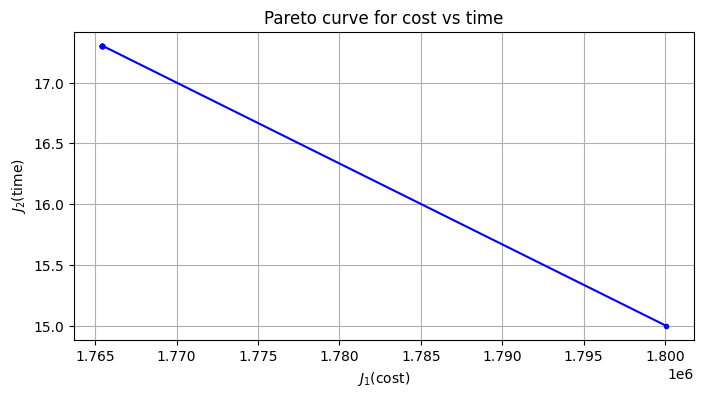

In [119]:
J1=m.addParameter('J1',description='cost')
J2=m.addParameter('J2',description='time')
iter = [i for i in range(5,51,5)]
sol1 = []
sol2 = []

for idx in iter:
    timeBound.setRecords(idx)
    MCNF.solve()
    if MCNF.status in [
        gp.ModelStatus.OptimalGlobal,
        gp.ModelStatus.OptimalLocal, gp.ModelStatus.Integer
    ]:
        J1[:]= Sum([comt,connectors,arcs[i,j]],beta[comt,connectors,i,j].l*wt[comt]*cost[connectors]
                         *distances[i,j])+Sum([connectors,i,j],maintenance[connectors]*alpha[connectors,i,j].l)
        J2[:]= time.l
        sol1.append(J1.toValue())
        sol2.append(J2.toValue())
    else:
        continue
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8,4))
ax.plot( sol1, sol2, "b.-" )
ax.set_xlabel("$J_1$(cost)")
ax.set_ylabel("$J_2$(time)")
ax.set_title("Pareto curve for cost vs time")
ax.grid();

Here we have saved the solutions for diffrent number of vehicles.

In [120]:
#v14
sol7=[1920527.6512702678, 1886392.7521226883, 1886392.7521226883, 1886392.7521226883, 1886392.7521226883, 1886392.7521226883, 1886392.7521226883, 1886392.7521226883]
sol8=[13.052228861869, 17.302951309145115, 17.302951309145115, 17.302951309145115, 17.302951309145115, 17.302951309145115, 17.302951309145115, 17.302951309145115]

In [121]:
#v15
sol1=[1847972.4223261464, 1814332.0291330956, 1814332.0291330956, 1814332.0291330956, 1814332.0291330956, 1814332.0291330956, 1814332.0291330956, 1814332.0291330956]
sol2=[13.052228861869, 17.302951309145115, 17.302951309145136, 17.302951309145115, 17.302951309145115, 17.302951309145115, 17.302951309145115, 17.302951309145115]

In [122]:
#v16
sol9=[1823774.8543614736, 1789639.955213894, 1789639.955213894, 1789639.955213894, 1789639.955213894, 1789639.955213894, 1789639.955213894, 1789639.955213894]
sol10=[13.052228861869, 17.302951309145115, 17.302951309145108, 17.302951309145115, 17.302951309145115, 17.302951309145115, 17.302951309145115, 17.302951309145115]

In [123]:
#v17
sol5=[1800048.3258817883, 1765442.387249221, 1765442.3872492209, 1765442.387249221, 1765442.387249221, 1765442.387249221, 1765442.387249221, 1765442.3872492209]
sol6=[13.052228861869, 17.302951309145115, 17.302951309145115, 17.302951309145115, 17.302951309145115, 17.302951309145115, 17.302951309145115, 17.302951309145115]

In [124]:
#v18
sol3=[1776498.3532209434, 1741892.414588376, 1741892.414588376, 1741892.414588376, 1741892.414588376, 1741892.414588376, 1741892.414588376, 1741892.414588376]
sol4=[13.052228861869, 17.302951309145115, 17.302951309145115, 17.302951309145115, 17.302951309145115, 17.302951309145115, 17.302951309145115, 17.302951309145115]

In [125]:
#v19
sol11=[1752798.2187650308, 1718342.4419275313, 1718342.441927531, 1718342.4419275313, 1718342.4419275313, 1718342.441927531, 1718342.4419275313, 1718342.4419275313]
sol12=[13.074178394679237, 17.302951309145115, 17.302951309145115, 17.302951309145115, 17.302951309145115, 17.302951309145115, 17.302951309145115, 17.302951309145115]

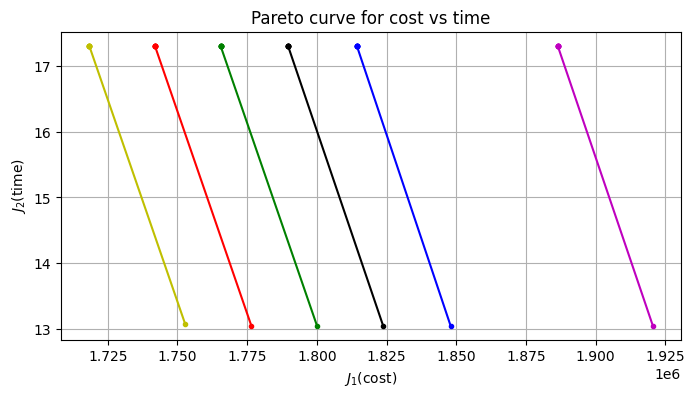

In [126]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot( sol1, sol2, "b.-" )
ax.plot( sol3, sol4, "r.-" )
ax.plot( sol5, sol6, "g.-" )
ax.plot( sol7, sol8, "m.-" )
ax.plot( sol9, sol10, "k.-" )
ax.plot( sol11, sol12, "y.-" )
ax.set_xlabel("$J_1$(cost)")
ax.set_ylabel("$J_2$(time)")
ax.set_title("Pareto curve for cost vs time")
ax.grid()

Lets analyze the pareto above using pivot tables. The table data has been extracted from the alpha values in the various scenarios seen above for teh pareto curve. The tables pasted are in the order when the total number of veicles at each node is decreased from 19 to 14. As we can see when we decrease the vehicles there is a decrease in the number of boats but an increase in the number of planes. This leads to a total increase in the cost as we decrease the number. Above we see a comparitively larger jump from 15 to 14 which can be explained by the pivot below which shows that now the increase in planes is by 3 instead of 2 as seen before. Thus, such a plotting can be used to take decisions regarding optimal vehicle placement at the nodes.

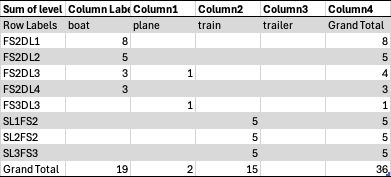

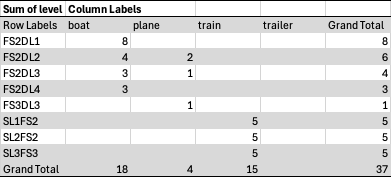

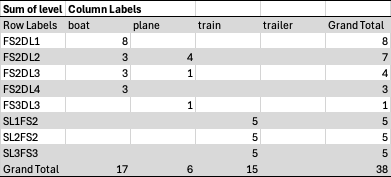

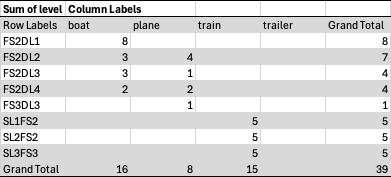

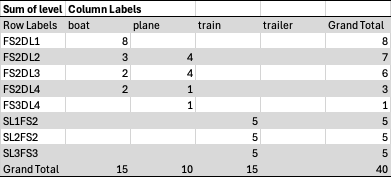

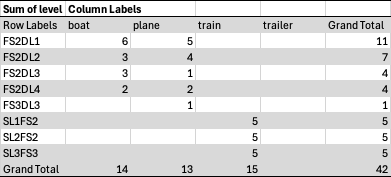

**D**

Assuming a stochastic nature of the demand thereby considering 5 scenarios of various demands for the DLs. We consider 5 scenarios with different demands and minimize the cost over the expected demand


In [127]:
m = gp.Container()
i = m.addSet('i', records=[
    [f"SL{x}"] for x in range(1, 4)
] + [
    [f"FS{y}"] for y in range(1, 5)
] + [
    [f"DL{z}"] for z in range(1, 5)
])
j = m.addAlias('j',i)
SL= m.addSet('SL',domain=[i],records=[[f"SL{x}"] for x in range(1, 4)])
FS= m.addSet('FS',domain=[i],records=[[f"FS{y}"] for y in range(1, 5)])
DL= m.addSet('DL',domain=[i],records=[[f"DL{z}"] for z in range(1, 5)])

ct= m.addSet('ct',records=['boat','plane','train','trailer'],description='Connector Types')

comt= m.addSet('comt',records=['fuel','troops','ammunition','weapons'],description='Commodity Types')

#ARCS
arcs = m.addSet('arcs', domain= [i,j])
arcs[SL,FS]=1
arcs[FS,DL]=1

connectors=m.addSet('connectors',records=[f'boat{x1}' for x1 in range(25)]+[f'plane{x2}'for x2 in range(25)]+[f'train{x3}'for x3 in range(25)]+[f'trailer{x4}'for x4 in range(25)])
ct1=m.addSet('ct1',domain=connectors,records=[f'boat{x1}' for x1 in range(25)],description='number of boats')
ct2=m.addSet('ct2',domain=connectors,records=[f'plane{x2}'for x2 in range(25)])
ct3=m.addSet('ct3',domain=connectors,records=[f'train{x3}'for x3 in range(25)])
ct4=m.addSet('ct4',domain=connectors,records=[f'trailer{x4}'for x4 in range(25)])
s=m.addSet('s',records=[0,1,2,3,4])

Notice that we have now defined all the relevant parameters, variables and equations on an added dimension ‘s’ which denotes the scenarios for the stochastic model. Also we now have the parameter probability ‘p’ which defines the probability over the 5 scenarios.

In [128]:
#variables
alpha = m.addVariable ('alpha','binary',domain=[connectors,i,j,s])
beta = m.addVariable ('beta','positive',domain=[comt,connectors,i,j,s])
total = Variable(m,"total","positive",domain=[comt,i,j,s])
#parameters
cost = m.addParameter('cost', domain=[connectors], records=np.repeat([3, 2.37, 0.05, 0.16], 25))
maintenance = m.addParameter ('maintenance',domain =[connectors],records =np.repeat(['75000','50000','1000','100'],25))
capacity = m.addParameter ('capacity', domain= [comt,connectors],records =np.repeat([[15.36,0,21.5,1.38],[500,75,1050,60],[50,19,70,4.5],[13888,5277,19440,1250]],25,axis=1))
max_capacity = m.addParameter ('max_capacity',domain = [connectors],records = np.repeat([50,19,70,4.5],25))
wt = m.addParameter ('wt',domain = [comt], records = np.array ([3.02,0.08,1,0.0036]))
demand = m.addParameter('demand', domain=[s,comt,DL], records = np.array([[[17,12,10,11],[750,500,300,250],[50,17,12,1],[10000,5122,5126,1563]],
 [[11,13,12,18],[700,430,350,450],[34,12,12,11],[11111,3212,4564,7827],],[[11,13,12,18],[750,500,300,250],[34,12,12,11],[10000,5122,5126,1563]],
  [[17,12,10,11],[700,430,350,450],[50,17,12,1],[11111,3212,4564,7827]],[[17,12,10,11],[550,800,200,150],[20,15,18,12],[10900,2122,1126,4563]]]))
velocity = m.addParameter('velocity', domain=[connectors], records=np.repeat([21,336,70,35],25))

p = gp.Parameter(m,'p',domain=s,description='probability',records=np.array([0.0,0.25,0.25,0.25,0.25]))


In [129]:
PlanesNoFuel = m.addEquation('PlanesNoFuel',domain = [s])
PlanesNoFuel[s]  = Sum([ct2,arcs[i,j]],beta['fuel',ct2,i,j,s])  == 0

TrainUse = m.addEquation('TrainUse',domain=[comt,s])
TrainUse[comt,s]  =  Sum([ct3,arcs[FS,DL]],beta[comt,ct3,FS,DL,s]) == 0

BoatUse = m.addEquation('BoatUse',domain=[comt,s])
BoatUse[comt,s]  = Sum([ct1,arcs[SL,FS]], beta[comt,ct1,SL,FS,s]) == 0

CapcityOnConnector = m.addEquation ('CapacityOnConnector',domain=[connectors,i,j,s])
CapcityOnConnector[connectors,arcs[i,j],s] =Sum(comt,beta[comt,connectors,i,j,s] * wt[comt]) <= max_capacity [connectors]

distances = m.addParameter('distances', domain=[i, j], records=np.array(list1).reshape(11, 11))

In [130]:
waterBwDL = m.addParameter('waterBwDL')
waterBwDL.setRecords(1)

if waterBwDL.toValue() == 0 :
  beta[comt,ct1,FS,DL,s].fx=0
else:
    alpha[ct3,FS,DL,s].fx=0
    alpha[ct4,FS,DL,s].fx=0
alpha[ct1,SL,FS,s].fx=0

In [131]:
total.up['fuel','SL1',FS,s] = 0
total.up['fuel','SL2',FS,s] = 0
total.up['troops','SL1',FS,s] = 0
total.up['troops','SL3',FS,s] = 0
total.up['ammunition','SL2',FS,s] = 0
total.up['ammunition','SL3',FS,s] = 0
total.up['weapons','SL2',FS,s] = 0
total.up['weapons','SL3',FS,s] = 0

In [132]:
#flow condition
FSFlow = m.addEquation('FSFlow',domain=[FS,s])
FSFlow[FS,s] = Sum([comt,connectors,SL], beta[comt,connectors,SL,FS,s]) - Sum([comt,connectors,DL],beta[comt,connectors,FS,DL,s]) <= 0
# demand conditions
demand_con1 = m.addEquation('demand_con1',domain=[comt,s])
demand_con1[comt,s] = Sum(arcs[SL,FS], total[comt,SL,FS,s])>=Sum(DL,demand[s,comt,DL])
demand_con2 = m.addEquation('demand_con2',domain=[comt,DL,s])
demand_con2[comt,DL,s] = Sum([FS], total[comt,FS,DL,s])>=demand[s,comt,DL]
totalSplit = m.addEquation('totalSplit',domain=[comt,i,j,s])
totalSplit[comt,arcs[i,j],s] = total[comt,i,j,s] == Sum(connectors,beta[comt,connectors,i,j,s])
alphaOn = m.addEquation('alphaOn',domain=[comt,connectors,i,j,s])
alphaOn[comt,connectors,arcs[i,j],s] = beta[comt,connectors,i,j,s]<=capacity[comt,connectors]*alpha[connectors,i,j,s]
oneConnector = m.addEquation('oneConnector',domain=[connectors,i,s])
oneConnector[connectors,i,s] = Sum(j,alpha[connectors,i,j,s])<=1

In [133]:
t1 = m.addVariable('t1',domain=[SL,FS,s])
t2 = m.addVariable('t2',domain=[FS,DL,s])
time = m.addVariable('time',domain=[s])

tVal1 = m.addEquation('tVal1',domain=[connectors,SL,FS,s])
tVal1[connectors,SL,FS,s] = t1[SL,FS,s] >= distances[SL,FS]/velocity[connectors] * alpha[connectors,SL,FS,s]
tVal2 = m.addEquation('tVal2',domain=[connectors,FS,DL,s])
tVal2[connectors,FS,DL,s] = t2[FS,DL,s] >= distances[FS,DL]/velocity[connectors] * alpha[connectors,FS,DL,s]

defTime = m.addEquation('defTime',domain=[SL,FS,DL,s])
defTime[SL,FS,DL,s] = time == t1[SL,FS,s] + t2[FS,DL,s]

General Ferris now demands knowing the least cost over the expected demand given certain demands which might emanate from the situation that has risen on the battlefield. We now optimize on cost considering the expected value of the demand considering the probability of each scenario.

In [134]:
!gamspy install solver xpress

Defaulting to user installation because normal site-packages is not writeable
  Using cached gamspy_xpress-54.1.0-py3-none-win_amd64.whl.metadata (61 bytes)
Using cached gamspy_xpress-54.1.0-py3-none-win_amd64.whl (10.0 MB)
  Attempting uninstall: gamspy-xpress
    Found existing installation: gamspy_xpress 54.1.0
    Uninstalling gamspy_xpress-54.1.0:
      Successfully uninstalled gamspy_xpress-54.1.0



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [135]:
MCNF = Model(m,equations=m.getEquations(),problem=Problem.MIP,sense=Sense.MIN,
             objective=Sum(s,p[s]*(Sum([comt,connectors,arcs[i,j]],beta[comt,connectors,i,j,s]*wt[comt]*cost[connectors]
                         *distances[i,j])+Sum([connectors,i,j],maintenance[connectors]*alpha[connectors,i,j,s]))))
MCNF.solve(options=Options(equation_listing_limit=100,relative_optimality_gap=0.12),solver="xpress",output=sys.stdout)

--- Job _xAqCeiXVQg_DRXdqS3DCDA.gms Start 07/10/26 14:01:31 54.1.0 37378ce0 WEX-WEI x86 64bit/MS Windows
--- Applying:
    C:\Users\biliy\AppData\Roaming\Python\Python314\site-packages\gamspy_base\gmsprmNT.txt
--- GAMS Parameters defined
    MIP xpress
    Input C:\Users\biliy\AppData\Local\Temp\tmpy72ifd68\_xAqCeiXVQg_DRXdqS3DCDA.gms
    Output C:\Users\biliy\AppData\Local\Temp\tmpy72ifd68\_xAqCeiXVQg_DRXdqS3DCDA.lst
    ScrDir C:\Users\biliy\AppData\Local\Temp\tmpy72ifd68\tmpzrd3emwm\
    SysDir C:\Users\biliy\AppData\Roaming\Python\Python314\site-packages\gamspy_base\
    LogOption 3
    License C:\Users\biliy\Documents\GAMSPy\gamspy_license.txt
    OptFile 0
    OptDir C:\Users\biliy\AppData\Local\Temp\tmpy72ifd68\
    LimRow 100
    LimCol 0
    GDX C:\Users\biliy\AppData\Local\Temp\tmpy72ifd68\_xAqCeiXVQg_DRXdqS3DCDAout.gdx
    OptCR 0.12
    SolPrint 0
    SolveLink 2
    PreviousWork 1
    gdxSymbols newOrChangedNoData
System information: 8 physical cores and 32 Gb physical mem

,Solver Status,Model Status,Objective,Num of Equations,Num of Variables,Model Type,Solver,Solver Time
0,NormalCompletion,OptimalGlobal,905866.934245,90466.0,117206.0,MIP,XPRESS,19.507


This is the minimum expected cost that will be incurred given the probabilities of the cenarios

**E**

General Ferris now wishes to know the least cost on the maximum demand from the list of scenarios he described earlier. Let us now consider the minimax of the scenarios we just considered in part D which gives us this value he asks for.

In [136]:
maxCost= m.addVariable('maxCost')
defmaxCost = m.addEquation('defmaxCost',domain=s)
defmaxCost[s] = maxCost >= (Sum([comt,connectors,arcs[i,j]],beta[comt,connectors,i,j,s]*wt[comt]*cost[connectors]
                         *distances[i,j])+Sum([connectors,i,j],maintenance[connectors]*alpha[connectors,i,j,s]))
MCNF1 = Model(m,equations=m.getEquations(),problem=Problem.MIP,sense=Sense.MIN,
             objective=maxCost)
MCNF1.solve(options=Options(equation_listing_limit=100,relative_optimality_gap=0.12),solver="xpress",output=sys.stdout)

--- _xAqCeiXVQg_DRXdqS3DCDA.gms(639) 51 Mb
--- Job _xAqCeiXVQg_DRXdqS3DCDA.gms Start 07/10/26 14:01:52 54.1.0 37378ce0 WEX-WEI x86 64bit/MS Windows
--- Applying:
    C:\Users\biliy\AppData\Roaming\Python\Python314\site-packages\gamspy_base\gmsprmNT.txt
--- GAMS Parameters defined
    MIP xpress
    Input C:\Users\biliy\AppData\Local\Temp\tmpy72ifd68\_xAqCeiXVQg_DRXdqS3DCDA.gms
    Output C:\Users\biliy\AppData\Local\Temp\tmpy72ifd68\_xAqCeiXVQg_DRXdqS3DCDA.lst
    ScrDir C:\Users\biliy\AppData\Local\Temp\tmpy72ifd68\tmpzrd3emwm\
    SysDir C:\Users\biliy\AppData\Roaming\Python\Python314\site-packages\gamspy_base\
    LogOption 3
    License C:\Users\biliy\Documents\GAMSPy\gamspy_license.txt
    OptFile 0
    OptDir C:\Users\biliy\AppData\Local\Temp\tmpy72ifd68\
    LimRow 100
    LimCol 0
    GDX C:\Users\biliy\AppData\Local\Temp\tmpy72ifd68\_xAqCeiXVQg_DRXdqS3DCDAout.gdx
    OptCR 0.12
    SolPrint 0
    SolveLink 2
    PreviousWork 1
    gdxSymbols newOrChangedNoData
System informati

,Solver Status,Model Status,Objective,Num of Equations,Num of Variables,Model Type,Solver,Solver Time
0,NormalCompletion,OptimalGlobal,932327.346139,90471.0,117207.0,MIP,XPRESS,43.322


This is the mimimum cost to fulfill the highest demand from the scenarios.

Note: The above two scenarios were solved with a relative optimality gap of 12%. The available solvers were unable to solve to optimality or 10% optimality gap.

This marks the end of the scope of considerations for this project and thus for General Ferris's optimization team.

**Conclusion**

General Ferris has now received all the data and insights he requested and is confident about the operation. He has tasked the team leader of Operation Wrath of Muggles with consolidating these findings for inclusion in his report to the president.

Through our analysis, we observed that the availability of vehicles impacts the operational cost. This is primarily due to the choice of vehicles to meet demand efficiently. For instance, in the Pareto curve model, we noticed no cost difference between having 14 and 15 vehicles of each type. However, when the number increased to 16, the cost decreased as the model identified a cheaper combination of vehicles to fulfill the demand. These variations are sensitive to changes in demand, enabling General Ferris to make informed decisions tailored to the specific needs of the operation.

The model also highlights how decisions regarding cost and time can be optimized based on scenario-specific requirements. Its robustness to varying parameters and conditions allows it to effectively handle diverse situations (A through E), ensuring operational efficiency. Depending on the demand, geographical constraints, and the nature of the area of impact, General Ferris can use this model to strategically position connectors (vehicles) across the supply chain to minimize costs and time.

For example, in the scenario analyzed with the Pareto curve, boats and planes proved to be critical in transporting commodities from FS to DL. While adding more boats beyond a certain threshold may not further reduce costs, a significant increase in demand would alter this dynamic due to the boats' higher capacity compared to planes.

These findings illustrate the model’s adaptability and its capacity to guide operational decisions under varying conditions. This concludes our analysis and provides General Ferris with a comprehensive framework for optimizing logistics in future operations.

We wish General Ferris good luck and thank him for all his hard work :)


***Further reading/extension***

This model explores some of the situations which General Ferris could face but there might be many such problems which might need optimization solutions, some of them are discussed below:

1. An enemy attack on one/muliple nodes which leads to abruptions in the material flow.
2. Congestion on the arcs leading to slower response time which is considered perfectly smooth in this model
3. Considering continuity of vehcles which would mean a vehicle could travel from SL to DL through an FS instead of vehicle switch at FS
4. We have another General asking for resources , so prioritizing between the two asks since the resources are limited and so are the vehicles transporting them
5. General Ferris has been appointed to lead two fronts now- one which he was taking care of already and now another on a different side of the planet- how do we optimize the commodity flow now?
6. Running DOE analysis by varying one parameter while keeping others constant in varios istuations to understand the impact of each and thus to gain more insight into the finer relationship between the moving parts of the model


**Bibliography:**

Data for capacities, costs, velocities, etc. of different vehicles were found from the following resources:  

Boat:

https://www.freightwaves.com/news/ship-fuel-cost-down-from-war-peak-but-green-fallout-looms#:~:text=VLSFO%20price%20back%20to%20pre%2Dwar%20levels&text=Ships%20with%20exhaust%2Dgas%20scrubbers,back%20to%20September%202021%20levels.&text=In%20the%20container%20shipping%20sector,2022%2C%20according%20to%20DPI%20data.

https://www.freightwaves.com/news/how-many-gallons-of-fuel-does-a-container-ship-carry#:~:text=The%20amount%20of%20fuel%20actually,it%20drops%20its%20speed%2010%25.

https://globalshift.co.uk/conv.html

Plane:

https://ig.space/commslink/c-130-hercules-lockheeds-do-everything-transport

https://www.af.mil/About-Us/Fact-Sheets/Display/Article/1555054/c-130-hercules/

Train:

https://www.rsilogistics.com/blog/comparing-the-costs-of-rail-shipping-vs-truck/#:~:text=bulk%20terminal%20network.-,Many%20shippers%20understand%20the%20savings%20potential%20in%20shipping%20rail%20versus,is%20$214.96%20per%20net%20ton.

https://quorumcorp.net/Downloads/Papers/RailwayCapacityOverview.pdf

https://en.wikipedia.org/wiki/Rail_speed_limits_in_the_United_States

Trailer:

https://www.nctrailers.com/blog/trailer-payload-capacity-a-quick-guide-to-determining-the-maximum-weight-your-trailer-can-carry/#:~:text=The%20formula%20to%20determine%20the,Determining%20the%20Trailer%20Weight:

https://www.trailersoftexas.com/media/pdfs/capacity-guide-info-chart.pdf

https://trucksmart.udot.utah.gov/stopping-distances/#:~:text=In%20comparison%2C%20a%20fully%20loaded%20tractor%2Dtrailer%20weighing,on%20the%20brake%20until%20the%20vehicle%20stops.



